In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


Combined shape: (2919, 80)


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


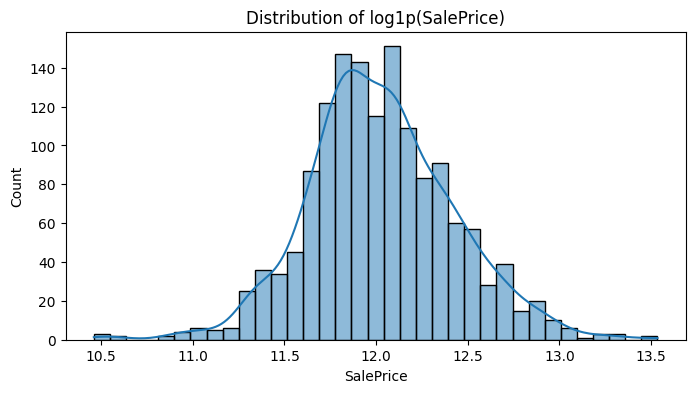

Train feats shape: (1460, 248) Test feats shape: (1459, 248)
Training Ridge & Lasso...
Ridge RMSE (val, log-space): 0.15576345803265257
Lasso RMSE (val, log-space): 0.1554161455972849
Training RandomForest...
RF RMSE (val, log-space): 0.14545174923061202
Training XGBoost...


`early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.


XGBoost RMSE (val, log-space): 0.14023771126518247
Starting OOF stacking...
Fold 1 RMSE: 0.15576
Fold 2 RMSE: 0.12705
Fold 3 RMSE: 0.19063
Fold 4 RMSE: 0.14599
Fold 5 RMSE: 0.13480
Fold 1 RMSE: 0.14745
Fold 2 RMSE: 0.12293
Fold 3 RMSE: 0.17597
Fold 4 RMSE: 0.14440
Fold 5 RMSE: 0.12033
Fold 1 RMSE: 0.14135
Fold 2 RMSE: 0.11726
Fold 3 RMSE: 0.16965
Fold 4 RMSE: 0.13258
Fold 5 RMSE: 0.11934
Meta features shapes: (1460, 3) (1459, 3)
Meta OOF RMSE (log-space): 0.13271397379772792
Saved stacked submission to submission_oof_stack.csv


<Figure size 800x1000 with 0 Axes>

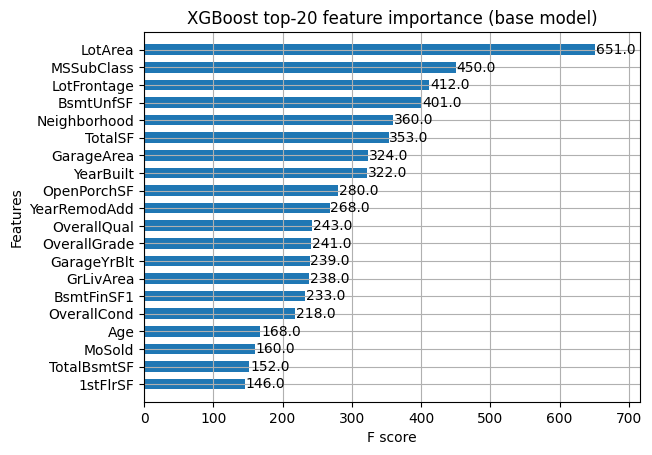

Computing SHAP values (sampled) — may take a while


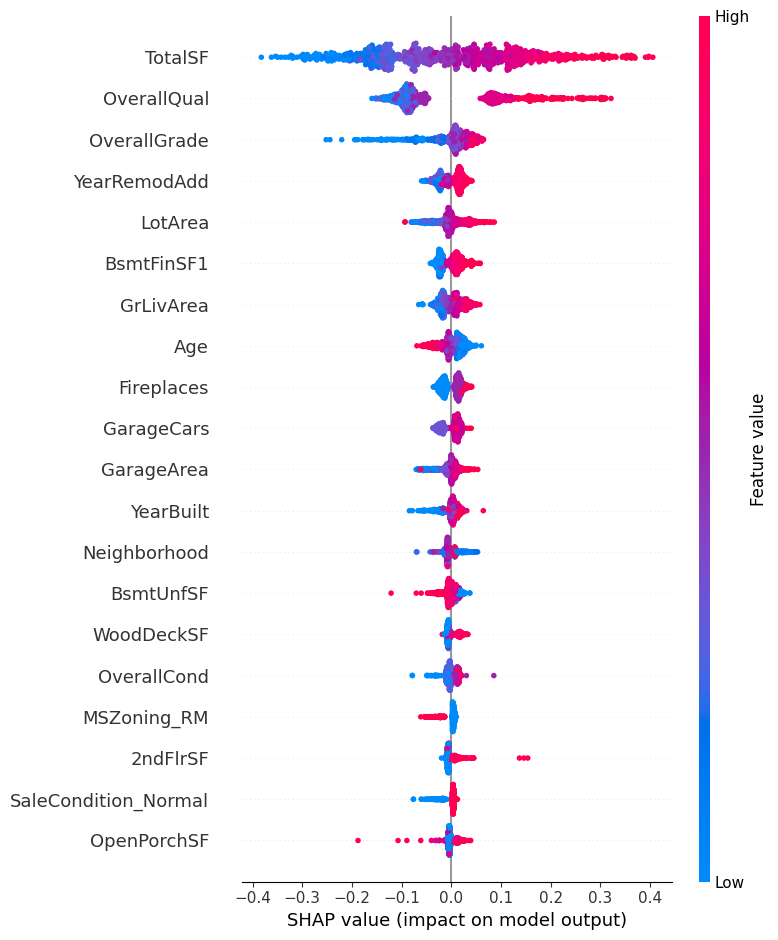

Local validation RMSEs (log-space):
Ridge (val): 0.15576345803265257
Lasso (val): 0.1554161455972849
RF (val): 0.14545174923061202
XGB (val): 0.14023771126518247
Meta (OOF) RMSE (log-space): 0.13271397379772792


In [2]:
# house_prices_full_pipeline.ipynb / .py
# End-to-end House Prices pipeline with OOF stacking
# Author: Seshasai (adapt & iterate)
# Notes: Run in a notebook for visual outputs. Set TRAIN_PATH and TEST_PATH accordingly.

# -----------------------------
# 0. Imports & settings
# -----------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

import xgboost as xgb

# Optional SHAP
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

RND = 42
np.random.seed(RND)

# -----------------------------
# 1. Paths & helper funcs
# -----------------------------
TRAIN_PATH = "/kaggle/input/house-prices-advanced-regression-techniques/train.csv"   # change if needed
TEST_PATH = "/kaggle/input/house-prices-advanced-regression-techniques/test.csv"     # change if needed
SUBMISSION_PATH = "submission_oof_stack.csv"

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def cv_rmse(model, X, y, folds=5):
    kf = KFold(n_splits=folds, shuffle=True, random_state=RND)
    scores = cross_val_score(model, X, y, scoring="neg_root_mean_squared_error", cv=kf, n_jobs=-1)
    return -scores.mean(), scores.std()

# -----------------------------
# 2. Load data
# -----------------------------
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
train_id = train['Id'].copy()
test_id = test['Id'].copy()

y = train['SalePrice'].copy()
train.drop(['SalePrice'], axis=1, inplace=True)

all_df = pd.concat([train, test], axis=0, ignore_index=True)
print("Combined shape:", all_df.shape)

# -----------------------------
# 3. Quick EDA plots (optional)
# -----------------------------
# Plot log1p(SalePrice) distribution
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(y), kde=True)
plt.title("Distribution of log1p(SalePrice)")
plt.show()

# -----------------------------
# 4. Feature engineering & cleaning
# -----------------------------
df = all_df.copy()

# Example derived features
if {'TotalBsmtSF','1stFlrSF','2ndFlrSF'}.issubset(df.columns):
    df['TotalSF'] = df['TotalBsmtSF'].fillna(0) + df['1stFlrSF'].fillna(0) + df['2ndFlrSF'].fillna(0)

if {'OverallQual','OverallCond'}.issubset(df.columns):
    df['OverallGrade'] = df['OverallQual'].fillna(0) * df['OverallCond'].fillna(0)

if {'YrSold','YearBuilt'}.issubset(df.columns):
    df['Age'] = df['YrSold'] - df['YearBuilt']

# Fill common categorical NAs with 'None'
cat_na_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu','GarageType',
               'GarageFinish','GarageQual','GarageCond','BsmtQual','BsmtCond',
               'BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType']
for col in cat_na_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# Numeric fills
num_fill_zero = ['LotFrontage','MasVnrArea','GarageYrBlt']
for col in num_fill_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Fill any remaining numeric with median
num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

# Fill remaining categorical with 'None'
cat_cols = df.select_dtypes(include=['object']).columns
for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna('None')

# Log transform skewed numeric features
numeric_feats = df.select_dtypes(include=[np.number]).columns
skewed_feats = df[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewed_feats = skewed_feats[abs(skewed_feats) > 0.75].index
for feat in skewed_feats:
    # avoid transforming Id
    if feat != 'Id':
        df[feat] = np.log1p(df[feat])

# One-hot encode low-cardinality categoricals
low_cardinality_cols = [c for c in cat_cols if df[c].nunique() < 20]
df = pd.get_dummies(df, columns=low_cardinality_cols, drop_first=True)

# Label encode remaining high-cardinality categoricals
high_card_cols = [c for c in cat_cols if c not in low_cardinality_cols]
for c in high_card_cols:
    if c in df.columns:  # some may have been removed by get_dummies
        le = LabelEncoder()
        df[c] = le.fit_transform(df[c].astype(str))

# Split back to train/test
n_train = train.shape[0]
train_feats = df.iloc[:n_train, :].copy()
test_feats = df.iloc[n_train:, :].copy()
print("Train feats shape:", train_feats.shape, "Test feats shape:", test_feats.shape)

# Drop Id if present
if 'Id' in train_feats.columns:
    train_feats = train_feats.drop(['Id'], axis=1)
if 'Id' in test_feats.columns:
    test_feats = test_feats.drop(['Id'], axis=1)

# -----------------------------
# 5. Prepare X, y (log target)
# -----------------------------
y_log = np.log1p(y)  # log-transform target
X = train_feats.copy()
X_test_final = test_feats.copy()

# Align columns (in case)
X, X_test_final = X.align(X_test_final, join='left', axis=1, fill_value=0)

# StandardScaler for linear models / stack consistency
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_final), columns=X_test_final.columns, index=X_test_final.index)

# Quick holdout split for sanity-check
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_log, test_size=0.2, random_state=RND)

# -----------------------------
# 6. Baseline models (Ridge, Lasso)
# -----------------------------
print("Training Ridge & Lasso...")
ridge = Ridge(alpha=10, random_state=RND)
ridge.fit(X_train, y_train)
ridge_preds_val = ridge.predict(X_val)
print("Ridge RMSE (val, log-space):", rmse(y_val, ridge_preds_val))

lasso = Lasso(alpha=0.001, random_state=RND, max_iter=10000)
lasso.fit(X_train, y_train)
lasso_preds_val = lasso.predict(X_val)
print("Lasso RMSE (val, log-space):", rmse(y_val, lasso_preds_val))

# -----------------------------
# 7. RandomForest baseline
# -----------------------------
print("Training RandomForest...")
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RND, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds_val = rf.predict(X_val)
print("RF RMSE (val, log-space):", rmse(y_val, rf_preds_val))

# -----------------------------
# 8. XGBoost baseline
# -----------------------------
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(n_estimators=800, learning_rate=0.05, max_depth=4, random_state=RND, n_jobs=-1)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
xgb_preds_val = xgb_model.predict(X_val)
print("XGBoost RMSE (val, log-space):", rmse(y_val, xgb_preds_val))

# -----------------------------
# 9. OOF stacking implementation (produce final submission)
# -----------------------------
print("Starting OOF stacking...")

from sklearn.model_selection import KFold

def get_oof(clf, X_full, y_full, X_test_full, n_folds=5):
    ntrain = X_full.shape[0]
    ntest = X_test_full.shape[0]
    oof_train = np.zeros(ntrain)
    oof_test = np.zeros((n_folds, ntest))
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=RND)
    for i, (train_idx, valid_idx) in enumerate(kf.split(X_full)):
        X_tr = X_full.iloc[train_idx]
        y_tr = y_full.iloc[train_idx]
        X_val_fold = X_full.iloc[valid_idx]
        y_val_fold = y_full.iloc[valid_idx]
        clf.fit(X_tr, y_tr)
        oof_train[valid_idx] = clf.predict(X_val_fold)
        oof_test[i, :] = clf.predict(X_test_full)
        fold_rmse = rmse(y_val_fold, oof_train[valid_idx])
        print(f"Fold {i+1} RMSE: {fold_rmse:.5f}")
    oof_test_mean = oof_test.mean(axis=0)
    return oof_train.reshape(-1,1), oof_test_mean.reshape(-1,1)

# Define base models with good defaults
ridge_base = Ridge(alpha=10, random_state=RND)
rf_base = RandomForestRegressor(n_estimators=400, max_depth=12, random_state=RND, n_jobs=-1)
xgb_base = xgb.XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=4, random_state=RND, n_jobs=-1)

# Generate OOF predictions for each base model
ridge_oof_train, ridge_oof_test = get_oof(ridge_base, X_scaled, y_log, X_test_scaled, n_folds=5)
rf_oof_train, rf_oof_test = get_oof(rf_base, X_scaled, y_log, X_test_scaled, n_folds=5)
xgb_oof_train, xgb_oof_test = get_oof(xgb_base, X_scaled, y_log, X_test_scaled, n_folds=5)

# Stack OOF features for meta-model
X_meta = np.concatenate([ridge_oof_train, rf_oof_train, xgb_oof_train], axis=1)
X_test_meta = np.concatenate([ridge_oof_test, rf_oof_test, xgb_oof_test], axis=1)
print("Meta features shapes:", X_meta.shape, X_test_meta.shape)

# Train meta-model
meta = Ridge(alpha=5, random_state=RND)
meta.fit(X_meta, y_log)
meta_oof_preds = meta.predict(X_meta)
print("Meta OOF RMSE (log-space):", rmse(y_log, meta_oof_preds))

# Predict on test set using meta-test features and back-transform
meta_test_preds_log = meta.predict(X_test_meta)
meta_test_preds = np.expm1(meta_test_preds_log)

# Save submission
submission = pd.DataFrame({'Id': test_id, 'SalePrice': meta_test_preds})
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Saved stacked submission to {SUBMISSION_PATH}")

# -----------------------------
# 10. Feature importance (XGBoost) & optional SHAP
# -----------------------------
plt.figure(figsize=(8,10))
try:
    xgb.plot_importance(xgb_base, max_num_features=20, height=0.6)
    plt.title("XGBoost top-20 feature importance (base model)")
    plt.show()
except Exception as e:
    print("XGBoost feature importance plot error:", e)

if HAS_SHAP:
    print("Computing SHAP values (sampled) — may take a while")
    sample_X = X_scaled.sample(1000, random_state=RND)
    explainer = shap.Explainer(xgb_base)
    shap_values = explainer(sample_X)
    shap.summary_plot(shap_values, sample_X)
else:
    print("SHAP not available — skip SHAP explanation")

# -----------------------------
# 11. Summary printout (local RMSEs)
# -----------------------------
print("Local validation RMSEs (log-space):")
print("Ridge (val):", rmse(y_val, ridge_preds_val))
print("Lasso (val):", rmse(y_val, lasso_preds_val))
print("RF (val):", rmse(y_val, rf_preds_val))
print("XGB (val):", rmse(y_val, xgb_preds_val))
print("Meta (OOF) RMSE (log-space):", rmse(y_log, meta_oof_preds))
